<a href="https://colab.research.google.com/github/Jagadeesh819/aiml/blob/main/Student_carrerpath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = []
for i in range(300):  # number of students
    maths = np.random.randint(40, 100)
    science = np.random.randint(40, 100)
    english = np.random.randint(40, 100)
    coding = np.random.randint(0, 2)
    creativity = np.random.randint(0, 2)
    communication = np.random.randint(0, 2)
    # 🎯 Career Logic
    if maths > 80 and science > 80 and coding == 1:
        career = "Engineer"
    elif science > 85 and maths > 75:
        career = "Doctor"
    elif coding == 1 and maths > 75:
        career = "Data Scientist"
    elif creativity == 1 and english > 70:
        career = "Artist"
    elif communication == 1 and english > 75:
        career = "Business"
    else:
        career = "Other"

    data.append([maths, science, english, coding, creativity, communication, career])

In [3]:
df = pd.DataFrame(data, columns=[
    "Maths", "Science", "English",
    "Coding", "Creativity", "Communication",
    "Career"
])

print(df.head())

   Maths  Science  English  Coding  Creativity  Communication          Career
0     80       78       55       0           1              0           Other
1     47       82       67       1           0              1           Other
2     64       90       97       1           1              1          Artist
3     91       77       40       1           1              1  Data Scientist
4     52       43       48       1           0              1           Other


In [4]:

df.to_csv("career_dataset.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [5]:
import pandas as pd

df = pd.read_csv('career_dataset.csv')
print(df.head())

   Maths  Science  English  Coding  Creativity  Communication          Career
0     80       78       55       0           1              0           Other
1     47       82       67       1           0              1           Other
2     64       90       97       1           1              1          Artist
3     91       77       40       1           1              1  Data Scientist
4     52       43       48       1           0              1           Other


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Career'] = le.fit_transform(df['Career'])

In [7]:
X = df.drop('Career', axis=1)
y = df['Career']

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(set(y)), activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4375 - loss: 1.7011 - val_accuracy: 0.5167 - val_loss: 1.5818
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5833 - loss: 1.4320 - val_accuracy: 0.5333 - val_loss: 1.3878
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6125 - loss: 1.2244 - val_accuracy: 0.5500 - val_loss: 1.2345
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6292 - loss: 1.0575 - val_accuracy: 0.6167 - val_loss: 1.1031
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6958 - loss: 0.9296 - val_accuracy: 0.6500 - val_loss: 0.9865
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7167 - loss: 0.8237 - val_accuracy: 0.6667 - val_loss: 0.8884
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7583 - loss: 0.7354 - val_accuracy: 0.6833 - val_loss: 0.7972
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7875 - loss: 0.6624 - val_accuracy: 0.7333 - val_los

In [13]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9500 - loss: 0.1415
Accuracy: 0.949999988079071


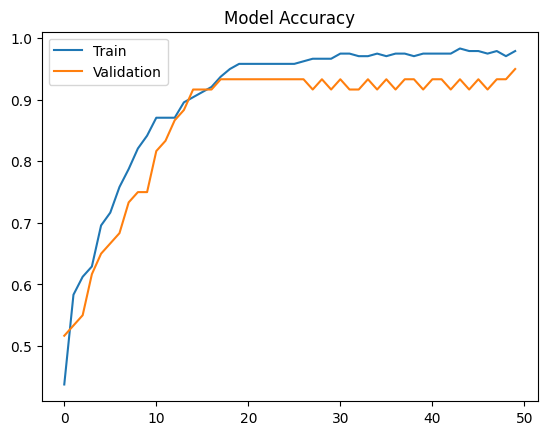

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [15]:

sample = [[85, 80, 75, 1, 0, 1]]  # new student
sample = scaler.transform(sample)

pred = model.predict(sample)

print("Career:", le.inverse_transform([pred.argmax()]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Career: ['Engineer']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
